# SimpleImputer — Mean, Median, Mode, Constant
### When to use which, and why imputation always changes the underlying distribution

**Core idea to remember for interviews:**
`SimpleImputer` replaces every missing value in a column with **one single fixed number**
(the column's mean, median, mode, or a constant you choose). It's fast and simple — but that
simplicity comes at a real cost: **it always distorts the original distribution** to some
degree, because you're injecting the *same* value into every missing slot instead of a
realistic, varied one.

We'll demonstrate this directly on real distributions below, not just state it.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from scipy import stats

np.random.seed(1)
plt.rcParams['figure.figsize'] = (7, 4)

## 1. Build a Synthetic Dataset

Three columns, each suited to a **different** imputation strategy, so the "when to use what"
guidance below isn't just a rule you memorize — you'll see *why* each rule exists.

- **`normal_col`** → symmetric, bell-shaped, no outliers → good candidate for **Mean**
- **`skewed_col`** → right-skewed with outliers (like income or house prices) → good candidate
  for **Median**
- **`cat_col`** → categorical variable → good candidate for **Mode** (or **Constant**, discussed
  later)


In [2]:
n = 1000

normal_col = np.random.normal(50, 10, n)
skewed_col = np.random.exponential(scale=20, size=n)
cat_col = np.random.choice(['Standard', 'Premium', 'Basic'], size=n, p=[0.55, 0.30, 0.15])

df = pd.DataFrame({
    'normal_col': normal_col,
    'skewed_col': skewed_col,
    'cat_col': cat_col
})

# Introduce ~20% missingness (MCAR, for simplicity, since we're focused on imputation mechanics here)
for col in ['normal_col', 'skewed_col', 'cat_col']:
    mask = np.random.rand(n) < 0.20
    df.loc[mask, col] = np.nan

print(df.isna().sum())
df.head()

normal_col    188
skewed_col    196
cat_col       194
dtype: int64


,normal_col,skewed_col,cat_col
0,66.243454,9.787456,Standard
1,43.882436,13.580187,Standard
2,44.718282,5.872342,Standard
3,39.270314,43.250641,NaN
4,58.654076,9.666267,Standard


---
## 2. Mean Imputation

**When to use:** Numeric column, roughly **symmetric / normally distributed**, **no significant
outliers**. Mean is sensitive to outliers, so a single extreme value can pull it far from what's
"typical" — don't use it on skewed data.

**Why it changes the distribution:** every missing value becomes the exact same number (the
mean) → this creates an artificial **spike at the mean** and **shrinks the variance**, because
you've replaced natural spread with a repeated constant.


Mean used for imputation: 50.28


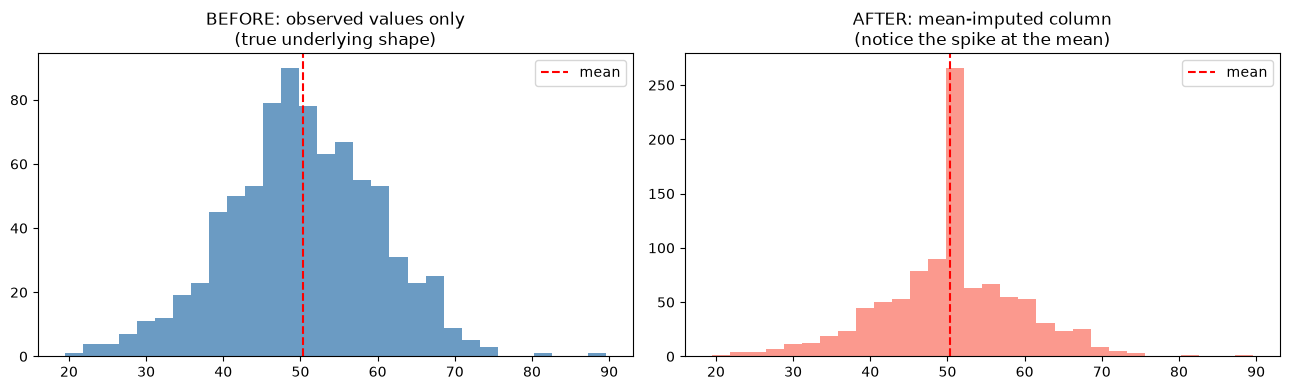

Std BEFORE (observed only): 9.83
Std AFTER (imputed column): 8.86
-> Variance shrinks after imputation. This is expected, but must be reported/understood,
   since it can make the data look 'more certain' than it really is (understated variance
   can distort downstream statistical tests and model confidence intervals).


In [3]:
imputer_mean = SimpleImputer(strategy='mean')
normal_col_imputed = imputer_mean.fit_transform(df[['normal_col']]).flatten()

print(f"Mean used for imputation: {imputer_mean.statistics_[0]:.2f}")

# Compare distribution BEFORE (only observed values) vs AFTER (full imputed column)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['normal_col'].dropna(), bins=30, color='steelblue', alpha=0.8)
axes[0].set_title("BEFORE: observed values only\n(true underlying shape)")
axes[0].axvline(df['normal_col'].dropna().mean(), color='red', linestyle='--', label='mean')
axes[0].legend()

axes[1].hist(normal_col_imputed, bins=30, color='salmon', alpha=0.8)
axes[1].set_title("AFTER: mean-imputed column\n(notice the spike at the mean)")
axes[1].axvline(imputer_mean.statistics_[0], color='red', linestyle='--', label='mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Std BEFORE (observed only): {df['normal_col'].dropna().std():.2f}")
print(f"Std AFTER (imputed column): {normal_col_imputed.std():.2f}")
print("-> Variance shrinks after imputation. This is expected, but must be reported/understood,")
print("   since it can make the data look 'more certain' than it really is (understated variance")
print("   can distort downstream statistical tests and model confidence intervals).")

---
## 3. Median Imputation

**When to use:** Numeric column that is **skewed** or has **outliers** (income, prices, house
sizes, etc.). Median is robust to extreme values — it only cares about the middle-ranked value,
so a handful of outliers won't drag it around the way they would the mean.

**Why it changes the distribution:** same issue as mean — every missing value becomes the exact
same number (the median), creating an artificial spike and reduced variance. Median just picks
a **better, more representative** single number for skewed data — it doesn't avoid the
distortion problem entirely.


Median used for imputation: 14.59
(Compare to mean of observed data: 20.33 -- notice mean is pulled higher by the right-skew/outliers)


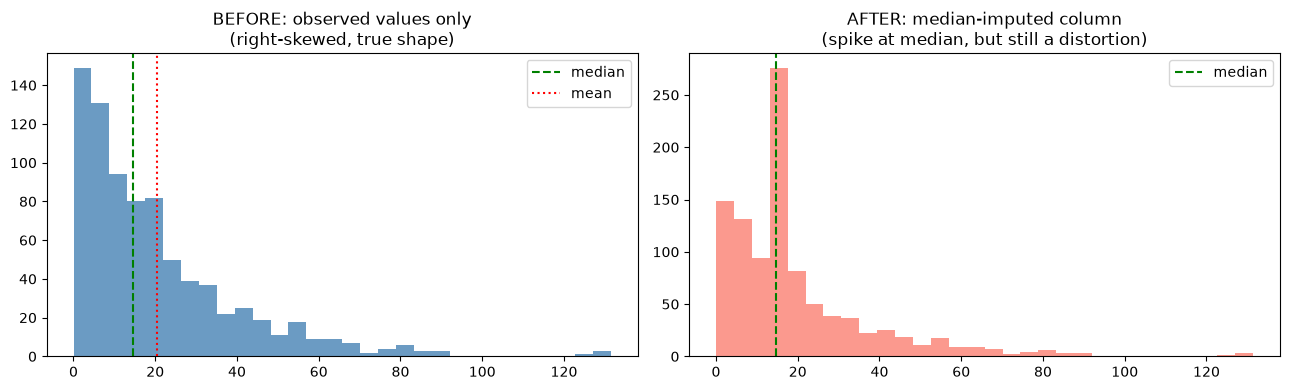


Skewness BEFORE: 1.87
Skewness AFTER:  2.21
-> Skewness is pulled toward 0 (less skewed) after imputation, because we added a pile
   of values at the median, which sits in the denser left part of a right-skewed curve.
   The shape has been altered, not preserved.


In [4]:
imputer_median = SimpleImputer(strategy='median')
skewed_col_imputed = imputer_median.fit_transform(df[['skewed_col']]).flatten()

print(f"Median used for imputation: {imputer_median.statistics_[0]:.2f}")
print(f"(Compare to mean of observed data: {df['skewed_col'].dropna().mean():.2f} "
      f"-- notice mean is pulled higher by the right-skew/outliers)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['skewed_col'].dropna(), bins=30, color='steelblue', alpha=0.8)
axes[0].set_title("BEFORE: observed values only\n(right-skewed, true shape)")
axes[0].axvline(df['skewed_col'].dropna().median(), color='green', linestyle='--', label='median')
axes[0].axvline(df['skewed_col'].dropna().mean(), color='red', linestyle=':', label='mean')
axes[0].legend()

axes[1].hist(skewed_col_imputed, bins=30, color='salmon', alpha=0.8)
axes[1].set_title("AFTER: median-imputed column\n(spike at median, but still a distortion)")
axes[1].axvline(imputer_median.statistics_[0], color='green', linestyle='--', label='median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSkewness BEFORE: {stats.skew(df['skewed_col'].dropna()):.2f}")
print(f"Skewness AFTER:  {stats.skew(skewed_col_imputed):.2f}")
print("-> Skewness is pulled toward 0 (less skewed) after imputation, because we added a pile")
print("   of values at the median, which sits in the denser left part of a right-skewed curve.")
print("   The shape has been altered, not preserved.")

---
## 4. Mode (Most Frequent) Imputation

**When to use:** **Categorical** columns (this is the *only* strategy `SimpleImputer` offers
that works natively on text/category data). Can also be used on discrete numeric data
(e.g., number of bedrooms) when one value clearly dominates.

**Why it changes the distribution:** it **exaggerates the dominant category even further** —
every missing entry gets assigned to whichever category was already most common, so that
category's share of the data grows artificially larger than it truly is.


Mode used for imputation: Standard


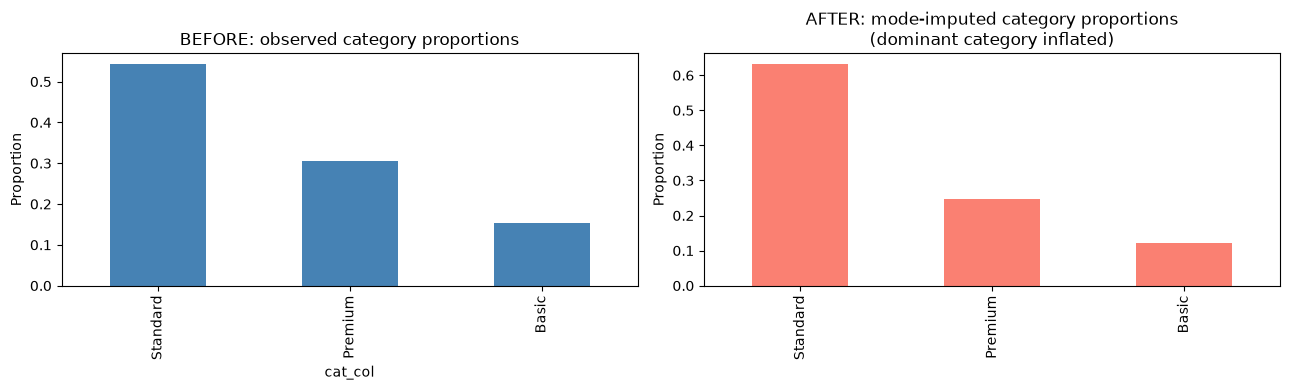


Proportion of the mode category:
  BEFORE: 54.2%
  AFTER:  63.1%
-> The dominant category's share grows -- this can be a real problem if that category
   is the majority class in a classification target, since it artificially worsens
   class imbalance.


In [5]:
imputer_mode = SimpleImputer(strategy='most_frequent')
cat_col_imputed = imputer_mode.fit_transform(df[['cat_col']]).flatten()

print(f"Mode used for imputation: {imputer_mode.statistics_[0]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

before_counts = df['cat_col'].dropna().value_counts(normalize=True)
after_counts = pd.Series(cat_col_imputed).value_counts(normalize=True)

before_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("BEFORE: observed category proportions")
axes[0].set_ylabel("Proportion")

after_counts.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("AFTER: mode-imputed category proportions\n(dominant category inflated)")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

print("\nProportion of the mode category:")
print(f"  BEFORE: {before_counts.iloc[0]:.1%}")
print(f"  AFTER:  {after_counts.iloc[0]:.1%}")
print("-> The dominant category's share grows -- this can be a real problem if that category")
print("   is the majority class in a classification target, since it artificially worsens")
print("   class imbalance.")

---
## 5. Constant Imputation

**When to use:**
1. When missingness **itself carries meaning** and you don't want to guess a "typical" value
   at all (e.g., a survey question left blank because it "doesn't apply" to the respondent).
2. When you want to **explicitly flag** imputed rows for a model to potentially learn from
   (e.g., filling categorical NaNs with `"Missing"` as its own category, or numeric NaNs with
   `-1` / `0` as a clear sentinel value that a tree-based model can split on).
3. Common in **tree-based models** (Random Forest, XGBoost) where an explicit "Missing" flag
   can actually be *informative* to the model, unlike in linear models where an arbitrary
   constant can distort coefficients badly.

**Why it changes the distribution:** this is the **most aggressive distortion** of the four —
you're not even trying to guess a realistic value. You're deliberately inserting an artificial
category/value. This is fine *only* when that's the explicit intent (flagging), not when you
want to preserve the data's natural shape.


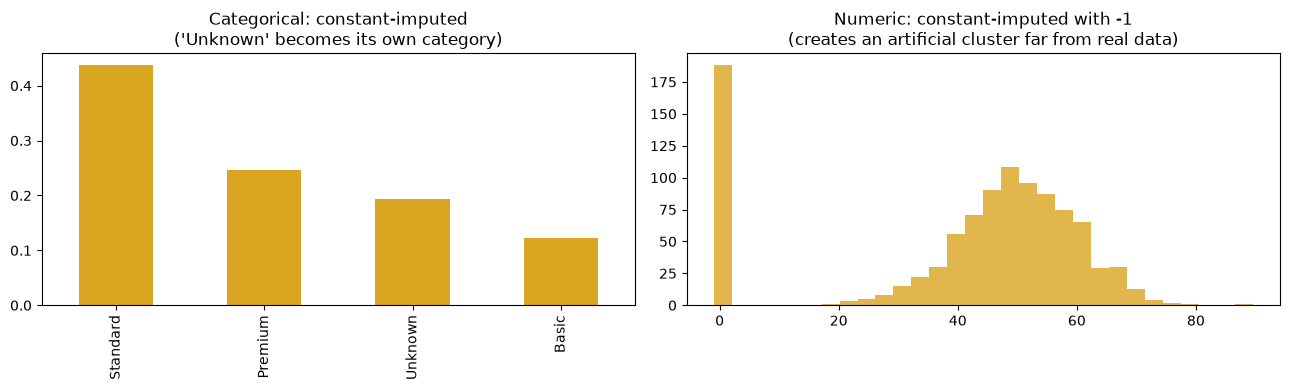

Notice the numeric case: a spike of values at -1, which is nowhere near the real
distribution (mean ~50). This would badly mislead a linear model if used blindly --
it's only safe here because -1 is meant purely as a 'this was missing' FLAG, often
combined with a separate binary 'was_missing' indicator column, not as a genuine value.


In [6]:
imputer_const_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
cat_col_const_imputed = imputer_const_cat.fit_transform(df[['cat_col']]).flatten()

imputer_const_num = SimpleImputer(strategy='constant', fill_value=-1)
normal_col_const_imputed = imputer_const_num.fit_transform(df[['normal_col']]).flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.Series(cat_col_const_imputed).value_counts(normalize=True).plot(
    kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title("Categorical: constant-imputed\n('Unknown' becomes its own category)")

axes[1].hist(normal_col_const_imputed, bins=30, color='goldenrod', alpha=0.8)
axes[1].set_title("Numeric: constant-imputed with -1\n(creates an artificial cluster far from real data)")

plt.tight_layout()
plt.show()

print("Notice the numeric case: a spike of values at -1, which is nowhere near the real")
print("distribution (mean ~50). This would badly mislead a linear model if used blindly --")
print("it's only safe here because -1 is meant purely as a 'this was missing' FLAG, often")
print("combined with a separate binary 'was_missing' indicator column, not as a genuine value.")

---
## 6. Side-by-Side: Does the Distribution Survive Imputation?

Let's put all the numbers in one table so the "distribution changes" claim isn't just
a statement — it's something you can quote with actual before/after numbers.


In [7]:
comparison = pd.DataFrame({
    'Statistic': ['Mean', 'Std Dev', 'Skewness'],
    'normal_col: BEFORE': [
        df['normal_col'].dropna().mean(),
        df['normal_col'].dropna().std(),
        stats.skew(df['normal_col'].dropna())
    ],
    'normal_col: AFTER (mean-imputed)': [
        normal_col_imputed.mean(),
        normal_col_imputed.std(),
        stats.skew(normal_col_imputed)
    ],
    'skewed_col: BEFORE': [
        df['skewed_col'].dropna().mean(),
        df['skewed_col'].dropna().std(),
        stats.skew(df['skewed_col'].dropna())
    ],
    'skewed_col: AFTER (median-imputed)': [
        skewed_col_imputed.mean(),
        skewed_col_imputed.std(),
        stats.skew(skewed_col_imputed)
    ],
})
comparison.set_index('Statistic').round(2)

,normal_col: BEFORE,normal_col: AFTER (mean-imputed),skewed_col: BEFORE,skewed_col: AFTER (median-imputed)
Statistic,,,,
Mean,50.28,50.28,20.33,19.21
Std Dev,9.83,8.86,19.81,17.89
Skewness,-0.08,-0.09,1.87,2.21


**Takeaway from the table above:** in every single case, standard deviation drops after
imputation. This isn't a bug or a mistake in the code — it's a **structural property of
`SimpleImputer`**: replacing missing values with one repeated constant can only ever shrink
variance, never preserve or increase it. This is the single most important limitation to state
out loud in an interview.


---
## 7. What To Do When Distribution Preservation Actually Matters

`SimpleImputer` is a fast, simple **baseline** — great for quick prototyping or when the
missing fraction is small enough that some distortion won't matter much downstream. When
preserving the distribution and relationships between variables matters more (e.g., for
statistical inference, or when missingness is substantial), consider:

- **`KNNImputer`** → fills missing values based on similar rows (nearest neighbors), producing
  more varied, realistic imputed values instead of one repeated constant.
- **`IterativeImputer` (MICE)** → models each column with missing values as a function of the
  other columns, iterating until convergence — captures relationships between variables far
  better than any single-statistic fill.
- **Adding a `"was_missing"` binary indicator column** alongside any imputation — this preserves
  the *information* that a value was missing (useful for MAR/MNAR cases), even though the
  imputed value itself is still an estimate.

None of these fully "solve" imputation — they just distort the distribution **less**, and in
smarter, more defensible ways than a single repeated constant.


---
## 8. Cheat Sheet — Which Strategy, When

| Strategy | Use when... | Distribution effect |
|---|---|---|
| **Mean** | Numeric, symmetric/normal, no outliers | Spike at mean, variance shrinks |
| **Median** | Numeric, skewed or has outliers | Spike at median, skewness pulled toward 0 |
| **Most Frequent (Mode)** | Categorical data (or discrete numeric with a dominant value) | Dominant category share inflated, worsens class imbalance |
| **Constant** | Missingness is meaningful, or you want an explicit "missing" flag for tree-based models | Most aggressive distortion — creates an artificial value/category with no natural relationship to the real data |

### One-line recall for interviews
*"SimpleImputer always shrinks variance and distorts shape, because it replaces every missing
value with the exact same number. Mean/Median/Mode just choose the least-bad single number for
symmetric/skewed/categorical data respectively — Constant is the odd one out, used when you
WANT to flag missingness rather than guess a value."*
